# 1.4 → 24.5 megasiemens por metro. La misma fibra de nanotubos. ¿Qué cambió entre medición y medición?

Un equipo del IMDEA Materiales en España metió un anión de aluminio (AlCl₄⁻) entre las paredes de nanotubos de carbono dobles y multiplicó la conductividad por 17. Llegaron al 41% del cobre con la mitad del peso.

**Paper:** *de Isidro-Gómez et al.* — "Intercalated carbon nanotube fibers with high specific electrical conductivity" · *Science*, 2026
**DOI:** [10.1126/science.aeb0673](https://doi.org/10.1126/science.aeb0673)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-23-nanotubos-carbono-conductividad/notebook.ipynb)

> *Pendiente — el video de Ciencia a Mordiscos sobre este paper aún no se publica.*

## El problema

Un nanotubo de carbono individual conduce la electricidad mejor que el cobre. El problema es que cuando los amontonas en una fibra macroscópica para hacer un cable de verdad, la conductividad se desploma — los electrones tienen que saltar entre nanotubos y ese salto cuesta caro.

El equipo aborda esto metiendo aniones AlCl₄⁻ (tetracloroaluminato — un átomo de aluminio rodeado de cuatro de cloro) en los huecos entre nanotubos. La idea es que esos aniones acepten electrones del nanotubo exterior, dejándolo "dopado" — con más portadores de carga libres. No es un enlace covalente, es una atracción electrostática.

Los datos de este notebook vienen del **Supplementary Material del paper** (todas las tablas — S1, S3 a S7). Trabajaremos con seis CSVs: la conductividad antes y después, las cargas DFT calculadas en simulación, los desplazamientos Raman experimentales que confirman el dopaje, una comparación con otros intercalantes ya probados en la literatura, y la comparación final del cable resultante con cables comerciales.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CONDUCTIVIDAD_COBRE_MS_M = 58.7          # Cobre puro 100% IACS, MS/m
CONDUCTIVIDAD_ESPECIFICA_COBRE_kS = 6.6  # kS·m²/kg (cobre = 6,600 S·m²/kg)
COLOR_DATOS = '#2563EB'                  # Azul CaM — datos del paper
COLOR_ALERTA = '#DC2626'                 # Rojo — referencia o anomalía
COLOR_REFERENCIA = '#D97706'             # Amber — umbrales
COLOR_CONTEXTO = '#BBBBBB'               # Gris — contexto/comparación
FUENTE = 'Fuente: de Isidro-Gómez et al. (2026), Science | Datos: Supplementary Material'

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'

# Estilo CaM (local → fallback a GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Descargar datos si faltan (Colab)
SLUG = '2026-04-23-nanotubos-carbono-conductividad'
os.makedirs('datos', exist_ok=True)
for csv in ['conductividad_pristine_vs_intercalado.csv', 'dft_charges.csv',
            'raman_peak_shifts.csv', 'comparacion_intercalantes.csv',
            'cable_materials.csv', 'comparacion_cables_18mm.csv']:
    p = f'datos/{csv}'
    if not os.path.exists(p):
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{csv}', p)

# Cargar
cond = pd.read_csv('datos/conductividad_pristine_vs_intercalado.csv')
dft = pd.read_csv('datos/dft_charges.csv')
raman = pd.read_csv('datos/raman_peak_shifts.csv')
inter = pd.read_csv('datos/comparacion_intercalantes.csv')
cables = pd.read_csv('datos/cable_materials.csv')
cables18 = pd.read_csv('datos/comparacion_cables_18mm.csv')

print(f'Conductividad: {len(cond)} filas (pristine + 3 niveles del CNTIC)')
print(f'DFT charges: {len(dft)} átomos en {dft.unit_id.nunique()} unidades AlCl4-')
print(f'Raman shifts: {len(raman)//2} energías de laser, 2 muestras cada una')
print(f'Intercalantes literatura: {len(inter)} entradas')
print(f'Materiales para cable: {len(cables)} candidatos')
print(f'Cables comerciales 18mm: {len(cables18)} (3 comerciales + 1 propuesto)')

Conductividad: 4 filas (pristine + 3 niveles del CNTIC)
DFT charges: 20 átomos en 4 unidades AlCl4-
Raman shifts: 3 energías de laser, 2 muestras cada una
Intercalantes literatura: 10 entradas
Materiales para cable: 4 candidatos
Cables comerciales 18mm: 4 (3 comerciales + 1 propuesto)


## El antes y el después

Aquí está.

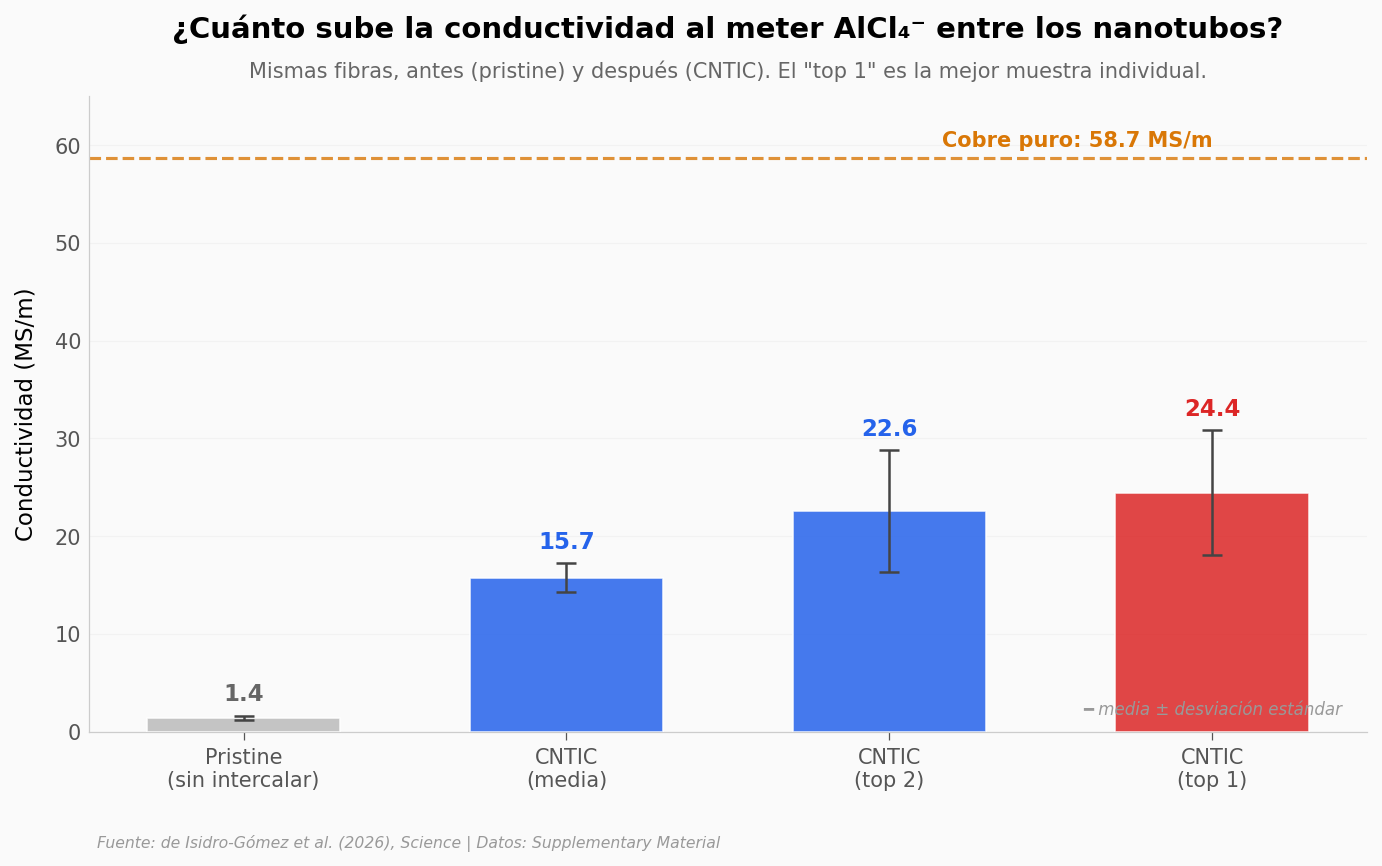

Factor de mejora — media CNTIC vs pristine: 11.2x
Factor de mejora — top 1 CNTIC vs pristine: 17.5x
La mejor muestra alcanza 41.6% de la conductividad del cobre.


In [2]:
fig, ax = plt.subplots(figsize=(11, 5.5))

samples = ['Pristine\n(sin intercalar)', 'CNTIC\n(media)', 'CNTIC\n(top 2)', 'CNTIC\n(top 1)']
values = cond['conductivity_MS_m'].values
errors = cond['conductivity_err'].values
colors = [COLOR_CONTEXTO, COLOR_DATOS, COLOR_DATOS, COLOR_ALERTA]
positions = np.arange(len(samples))

# Barras con error bars
for i, (pos, val, err, c) in enumerate(zip(positions, values, errors, colors)):
    ax.bar(pos, val, color=c, alpha=0.85, edgecolor='white', linewidth=0.8, width=0.6, zorder=3)
    ax.errorbar(pos, val, yerr=err, fmt='none', ecolor='#444444',
                capsize=5, capthick=1.2, lw=1.2, zorder=4)
    ax.text(pos, val + err + 1.5, f'{val:.1f}', ha='center', fontsize=11,
            fontweight='bold', color=c if c != COLOR_CONTEXTO else '#666666')

# Línea de referencia: cobre
ax.axhline(y=CONDUCTIVIDAD_COBRE_MS_M, color=COLOR_REFERENCIA, linestyle='--',
           linewidth=1.5, alpha=0.8, zorder=2)
ax.text(len(samples)-1, CONDUCTIVIDAD_COBRE_MS_M + 1.2,
        f'Cobre puro: {CONDUCTIVIDAD_COBRE_MS_M} MS/m',
        ha='right', fontsize=10, color=COLOR_REFERENCIA, fontweight='bold')

ax.set_xticks(positions)
ax.set_xticklabels(samples, fontsize=10)
ax.set_ylabel('Conductividad (MS/m)', fontsize=11)
ax.set_title('¿Cuánto sube la conductividad al meter AlCl₄⁻ entre los nanotubos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Mismas fibras, antes (pristine) y después (CNTIC). El "top 1" es la mejor muestra individual.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 65)
ax.grid(True, axis='y', alpha=0.3)

ax.text(0.98, 0.02, '━ media ± desviación estándar', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_conductividad_antes_despues.png', dpi=200, bbox_inches='tight')
plt.show()

# Calcular factor de mejora
factor_top = cond.iloc[3]['conductivity_MS_m'] / cond.iloc[0]['conductivity_MS_m']
factor_mean = cond.iloc[1]['conductivity_MS_m'] / cond.iloc[0]['conductivity_MS_m']
pct_cobre = 100 * cond.iloc[3]['conductivity_MS_m'] / CONDUCTIVIDAD_COBRE_MS_M
print(f'Factor de mejora — media CNTIC vs pristine: {factor_mean:.1f}x')
print(f'Factor de mejora — top 1 CNTIC vs pristine: {factor_top:.1f}x')
print(f'La mejor muestra alcanza {pct_cobre:.1f}% de la conductividad del cobre.')

La media del CNTIC está alrededor de 16 MS/m — un factor 11x sobre la fibra sin intercalar. La mejor muestra individual llega a 24.4 MS/m, que es casi un factor 17. Sigue por debajo del cobre (la línea naranja en 58.7 MS/m), pero ya está en el orden de magnitud. Cuarenta y un por ciento del cobre, en una fibra de carbono.

El paper enmarca el top 1 como **estimación más alta lograda** — no la media de fabricación. Las barras de error reflejan dispersión entre muestras: el proceso todavía no es uniforme. Cuando hablemos de "lo que se puede esperar de una fábrica" usaremos la media (~16 MS/m); cuando hablemos del techo del mecanismo, el top 1 (~24 MS/m).

Eso por sí solo ya es interesante. Pero la pregunta inevitable es **cómo** hace eso un anión metido entre tubos. Bajemos a la escala atómica.

## El truco a nivel atómico

El AlCl₄⁻ es un anión: un átomo de aluminio compartiendo electrones con cuatro de cloro. La carga neta del grupo entero es −1 — es decir, le sobra un electrón. Pero las simulaciones DFT (teoría del funcional de la densidad — el método estándar de química cuántica computacional) calculan la carga real átomo por átomo cuando el anión está rodeado de nanotubos. Y ahí aparece el detalle: los aniones no se quedan con todos los electrones que les corresponden por estequiometría. Aceptan más.

Veamos los números atómicos del unit cell simulado.

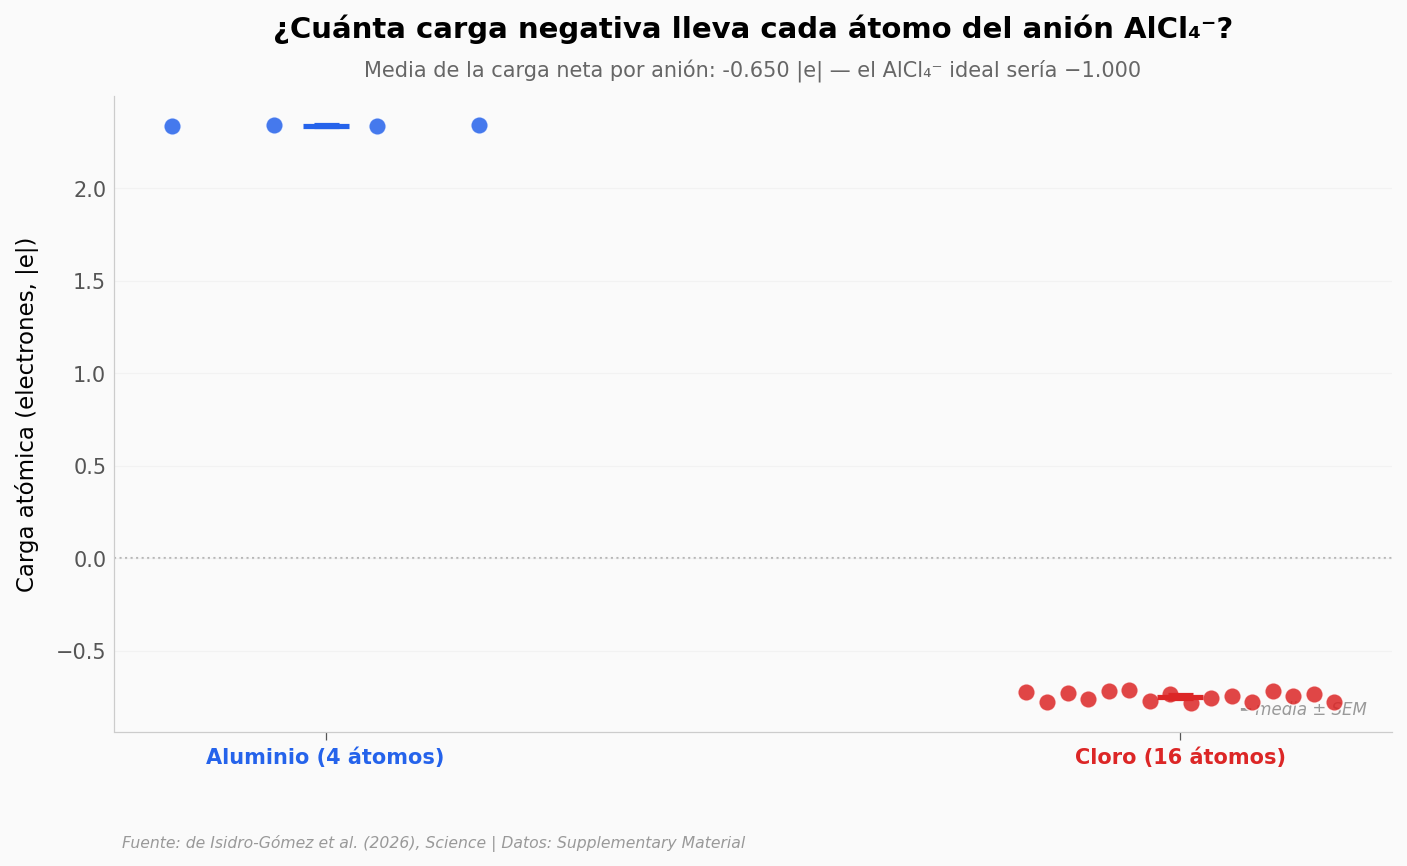

Carga media Al: +2.338 |e| (n=4)
Carga media Cl: -0.747 |e| (n=16)
Carga neta por anión AlCl4-: -0.650 |e|
Diferencia respecto al -1.000 ideal: 0.350 |e|
→ los nanotubos cedieron ~350 milielectrones por anión.


In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Separar Al de Cl
al = dft[dft['atom'] == 'Al']
cl = dft[dft['atom'] == 'Cl']

# Posiciones con jitter reproducible
np.random.seed(42)
def spread(n, center, width=0.18):
    x = np.linspace(center - width, center + width, n)
    np.random.shuffle(x)
    return x

ax.scatter(spread(len(al), 0), al['charge_e'], color=COLOR_DATOS, s=70,
           alpha=0.85, edgecolors='white', linewidths=0.7, zorder=5, label='Al')
ax.scatter(spread(len(cl), 1), cl['charge_e'], color=COLOR_ALERTA, s=70,
           alpha=0.85, edgecolors='white', linewidths=0.7, zorder=5, label='Cl')

# Medias y SEM
for i, (atoms, name, color) in enumerate([(al, 'Al', COLOR_DATOS),
                                           (cl, 'Cl', COLOR_ALERTA)]):
    m = atoms['charge_e'].mean()
    sem = atoms['charge_e'].std(ddof=1) / np.sqrt(len(atoms))
    ax.errorbar(i, m, yerr=sem, fmt='_', color=color,
                markersize=22, markeredgewidth=2.5,
                capsize=6, capthick=1.5, zorder=6)

# Net charge per AlCl4-
net = dft.groupby('unit_id')['charge_e'].sum()
ax.axhline(y=0, color='#999999', linestyle=':', linewidth=1, alpha=0.7, zorder=1)

# Labels en xticks (no Y hardcoded)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Aluminio (4 átomos)', 'Cloro (16 átomos)'], fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), [COLOR_DATOS, COLOR_ALERTA]):
    tick.set_color(color)

ax.set_ylabel('Carga atómica (electrones, |e|)', fontsize=11)
ax.set_title('¿Cuánta carga negativa lleva cada átomo del anión AlCl₄⁻?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Media de la carga neta por anión: {net.mean():.3f} |e| — el AlCl₄⁻ ideal sería −1.000',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(True, axis='y', alpha=0.3)
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_dft_charges.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadísticas
print(f'Carga media Al: +{al["charge_e"].mean():.3f} |e| (n={len(al)})')
print(f'Carga media Cl: {cl["charge_e"].mean():.3f} |e| (n={len(cl)})')
print(f'Carga neta por anión AlCl4-: {net.mean():.3f} |e|')
print(f'Diferencia respecto al -1.000 ideal: {1 + net.mean():.3f} |e|')
print(f'→ los nanotubos cedieron ~{(1 + net.mean())*1000:.0f} milielectrones por anión.')

La carga neta promedio por anión sale en **−0.65 |e|** — que coincide con los 0.65 electrones por anión del abstract. Eso significa que los nanotubos no le entregaron al anión solo el electrón que le corresponde por ser un anión: le dieron 0.35 electrones más de los que pedía. Esos electrones extra "salen" del nanotubo y dejan huecos — y los huecos son portadores de carga. Más portadores, más conducción.

Hasta aquí es simulación. La pregunta es si eso ocurre de verdad en la fibra real. Para verlo, el equipo midió Raman — una técnica que detecta vibraciones de los enlaces de carbono. Cuando un nanotubo cede electrones (se dopa tipo p), el modo G (la vibración característica del grafeno alrededor de 1580 cm⁻¹) se desplaza a frecuencias más altas. Veamos por cuánto.

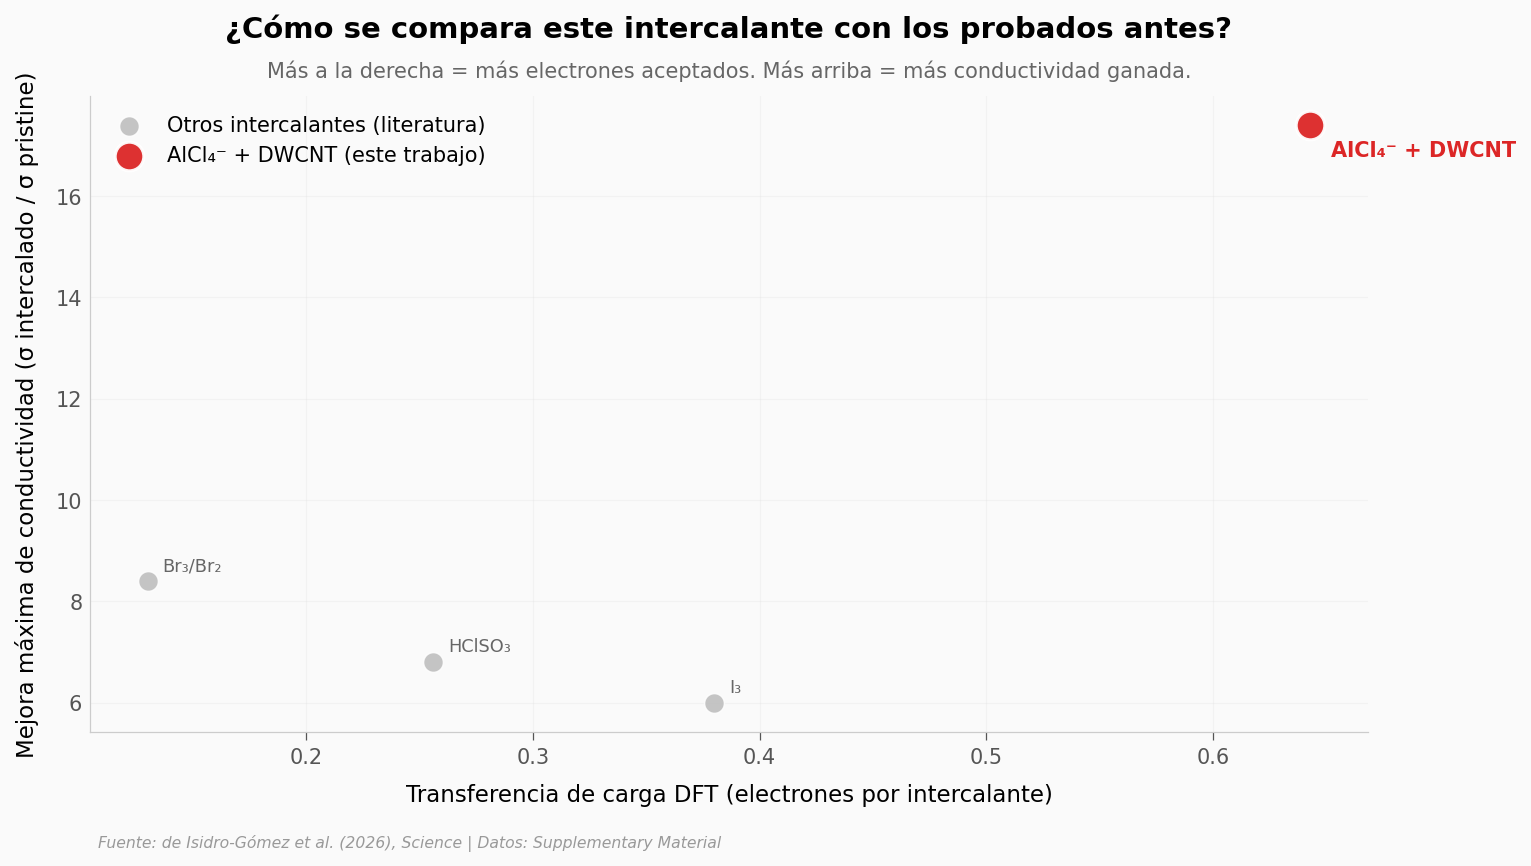

Intercalantes en la comparación con datos completos: 4
Mejora máxima reportada para AlCl4-/DWCNT (este trabajo): 17.4x
Mejor de la literatura previa: 8.4x


In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Filtrar entradas con datos completos en ambas variables
good = inter.dropna(subset=['charge_transfer_dft_e_per_intercalant', 'sigma_ratio_max']).copy()

# Destacar este trabajo
this_work = good[good['intercalante'].str.contains('this_work')]
others = good[~good['intercalante'].str.contains('this_work')]

ax.scatter(others['charge_transfer_dft_e_per_intercalant'],
           others['sigma_ratio_max'],
           color=COLOR_CONTEXTO, s=90, alpha=0.85,
           edgecolors='white', linewidths=0.7, zorder=4, label='Otros intercalantes (literatura)')

ax.scatter(this_work['charge_transfer_dft_e_per_intercalant'],
           this_work['sigma_ratio_max'],
           color=COLOR_ALERTA, s=190, alpha=0.95,
           edgecolors='white', linewidths=1.5, zorder=5, label='AlCl₄⁻ + DWCNT (este trabajo)')

# Etiquetas inline para los puntos
for _, row in others.iterrows():
    label = row['intercalante'].replace('_', ' ').replace('CNTIC', '').strip()
    if 'AlCl3' in label and 'electrochem' in label:
        label = 'AlCl₃ (grafito, electroquímico)'
    elif 'AlCl3' in label:
        label = 'AlCl₃ (grafito)'
    elif 'Br3' in label:
        label = 'Br₃/Br₂'
    elif 'I3' in label:
        label = 'I₃'
    elif 'HClSO3' in label:
        label = 'HClSO₃'
    elif 'FeCl3' in label:
        label = 'FeCl₃'
    elif 'Li' in label:
        label = 'Li'
    ax.annotate(label,
                (row['charge_transfer_dft_e_per_intercalant'], row['sigma_ratio_max']),
                xytext=(7, 5), textcoords='offset points',
                fontsize=8.5, color='#666666')

for _, row in this_work.iterrows():
    ax.annotate('AlCl₄⁻ + DWCNT',
                (row['charge_transfer_dft_e_per_intercalant'], row['sigma_ratio_max']),
                xytext=(10, -15), textcoords='offset points',
                fontsize=10, color=COLOR_ALERTA, fontweight='bold')

ax.set_xlabel('Transferencia de carga DFT (electrones por intercalante)', fontsize=11)
ax.set_ylabel('Mejora máxima de conductividad (σ intercalado / σ pristine)', fontsize=11)
ax.set_title('¿Cómo se compara este intercalante con los probados antes?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Más a la derecha = más electrones aceptados. Más arriba = más conductividad ganada.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_intercalantes.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Intercalantes en la comparación con datos completos: {len(good)}')
print(f'Mejora máxima reportada para AlCl4-/DWCNT (este trabajo): {this_work["sigma_ratio_max"].iloc[0]:.1f}x')
print(f'Mejor de la literatura previa: {others["sigma_ratio_max"].max():.1f}x')

La diagonal del plot lo dice: a más transferencia de carga, más mejora de conductividad. El AlCl₄⁻ aceptando 0.64 electrones empuja la fibra a un factor 17.4 — más alto que cualquier intercalante previo en CNT o grafito.

Pero un factor 17 en laboratorio no significa nada si el cable no llega a aplicaciones reales. La métrica que importa para una línea eléctrica no es la conductividad bruta — es la **conductividad específica** (cuánta corriente lleva por unidad de masa). Un cable más liviano ahorra acero en las torres y permite tendidos más largos.

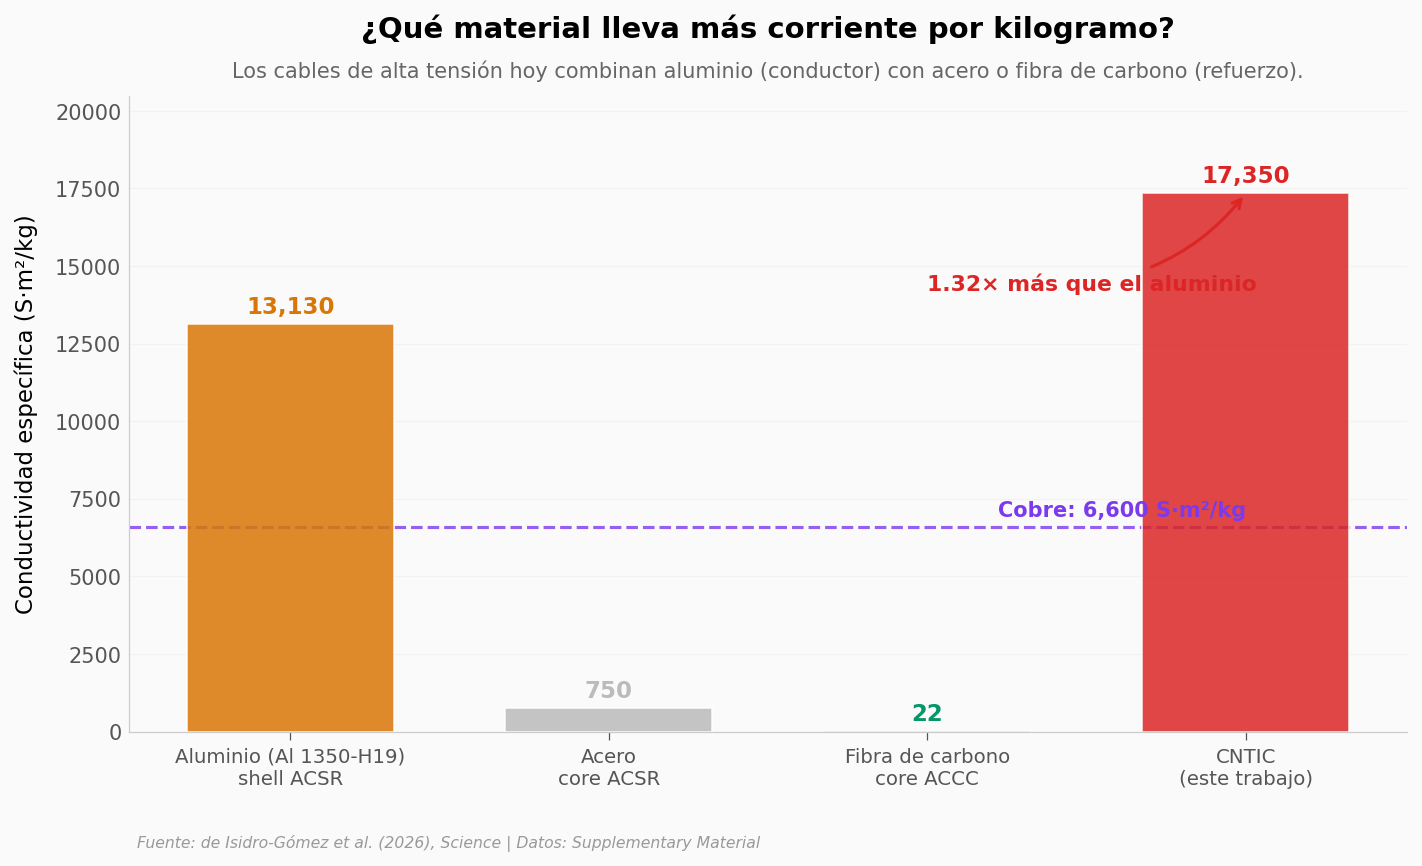

Conductividad específica CNTIC: 17,350 S·m²/kg
Conductividad específica aluminio: 13,130 S·m²/kg
Conductividad específica cobre: 6,600 S·m²/kg
CNTIC supera al aluminio por factor 1.32
CNTIC supera al cobre por factor 2.63


In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Datos: specific_electrical_conductivity de los 4 candidatos
materials = cables.copy()
labels = {
    'Al_1350-H19': 'Aluminio (Al 1350-H19)\nshell ACSR',
    'Steel': 'Acero\ncore ACSR',
    'CF_composite': 'Fibra de carbono\ncore ACCC',
    'CNTIC_this_work': 'CNTIC\n(este trabajo)',
}
colors_map = {'Al_1350-H19': COLOR_REFERENCIA, 'Steel': COLOR_CONTEXTO,
              'CF_composite': '#059669', 'CNTIC_this_work': COLOR_ALERTA}

positions = np.arange(len(materials))
values = materials['specific_electrical_conductivity_S_m2_kg'].values
mat_keys = materials['material'].values

bars = ax.bar(positions, values,
              color=[colors_map[m] for m in mat_keys],
              alpha=0.85, edgecolor='white', linewidth=0.8, width=0.65, zorder=3)

# Etiquetas con valor encima
for pos, val, m in zip(positions, values, mat_keys):
    ax.text(pos, val + max(values)*0.02, f'{int(val):,}',
            ha='center', fontsize=11, fontweight='bold',
            color=colors_map[m])

# Línea cobre
cobre_specific = CONDUCTIVIDAD_ESPECIFICA_COBRE_kS * 1000
ax.axhline(y=cobre_specific, color='#7C3AED', linestyle='--',
           linewidth=1.5, alpha=0.8, zorder=2)
ax.text(len(materials)-1, cobre_specific + max(values)*0.02,
        f'Cobre: {cobre_specific:,.0f} S·m²/kg',
        ha='right', fontsize=10, color='#7C3AED', fontweight='bold')

ax.set_xticks(positions)
ax.set_xticklabels([labels[m] for m in mat_keys], fontsize=9.5)
ax.set_ylabel('Conductividad específica (S·m²/kg)', fontsize=11)
ax.set_title('¿Qué material lleva más corriente por kilogramo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Los cables de alta tensión hoy combinan aluminio (conductor) con acero o fibra de carbono (refuerzo).',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(values) * 1.18)

# Anotación: superior a metales
cntic_idx = list(mat_keys).index('CNTIC_this_work')
al_idx = list(mat_keys).index('Al_1350-H19')
mejora = values[cntic_idx] / values[al_idx]
ax.annotate(f'{mejora:.2f}× más que el aluminio',
            xy=(cntic_idx, values[cntic_idx]),
            xytext=(cntic_idx - 1.0, values[cntic_idx] - max(values)*0.18),
            fontsize=10.5, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5,
                            connectionstyle='arc3,rad=0.2'))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_conductividad_especifica.png', dpi=200, bbox_inches='tight')
plt.show()

# Anomalía cuantificada
print(f'Conductividad específica CNTIC: {values[cntic_idx]:,.0f} S·m²/kg')
print(f'Conductividad específica aluminio: {values[al_idx]:,.0f} S·m²/kg')
print(f'Conductividad específica cobre: {cobre_specific:,.0f} S·m²/kg')
print(f'CNTIC supera al aluminio por factor {values[cntic_idx]/values[al_idx]:.2f}')
print(f'CNTIC supera al cobre por factor {values[cntic_idx]/cobre_specific:.2f}')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| El AlCl₄⁻ acepta ≈0.65 electrones por anión | ✅ | DFT del paper: net charge = −0.647 \|e\| en n=4 unidades. Coincide con el valor reportado en el abstract (0.65) |
| La conductividad sube ~17× con la intercalación | ✅ | Top 1: 24.44 / 1.40 = 17.5×. Media: 15.73 / 1.40 = 11.2×. El factor "17" del título usa la mejor muestra individual, no la media |
| La mejor muestra alcanza 41% del cobre | ✅ | 24.44 / 58.7 = 41.6%. Coincide con el abstract |
| La conductividad específica supera al aluminio | ✅ | 17,350 vs 13,130 S·m²/kg → 1.32× sobre el aluminio. Sigue por debajo del cobre (6,600), pero cuando importa el peso (cables aéreos) gana |
| El cable propuesto pesa la mitad y aguanta más | ⚠️ | Tabla S7 (`comparacion_cables_18mm.csv`): CNTIC 295 kg/km vs Wolf 726 kg/km (40%). Breaking load 349 kN vs 69.2 kN (5.0×). Pero **el cable CNTIC es proyección**, no construido |
| 80% de conductividad retenida con humedad | ⚠️ | Reportado en el abstract pero no aparece en las tablas extraídas. No verificable desde los datos del SM que tenemos |

> **Limitaciones honestas:**
> - El "top 1" representa el techo del mecanismo, no la media de fabricación. Tomar la media (~16 MS/m) para hablar de viabilidad industrial.
> - El cable de 18 mm es una **proyección a partir de la conductividad específica medida**, no un cable construido y testeado.
> - El método de transferencia de carga (DFT) tiene su propio modelo (Bader, Mulliken, Hirshfeld dan números diferentes). El paper usa Bader; el "0.65 e⁻" podría diferir 10-20% con otros métodos.
> - Estabilidad reportada solo en condiciones secas — el dopaje se degrada con humedad sin la cubierta polimérica.

## Ahora tú

Tres preguntas que los datos pueden responder. Los CSV ya están cargados — modifica la celda de configuración o esta de abajo:

1. **¿Qué pasa si el cobre puro no es la referencia justa?** Cambia `CONDUCTIVIDAD_COBRE_MS_M` en la celda de configuración a 35.45 (aluminio puro) y vuelve a ejecutar la gráfica hero. El CNTIC top 1 *supera* al aluminio puro.
2. **¿Hay correlación entre Δ pico Raman y mejora de conductividad?** El CSV `raman_peak_shifts.csv` tiene `delta_peak4_cm_inv` para 3 energías de laser. Cruza con `inv_q_ratio` para ver el dopaje en función de la energía.
3. **¿Cuánto del peso del cable se ahorra realmente?** Calcula `(cables18.iloc[1].net_weight_kg_km - cables18.iloc[3].net_weight_kg_km) / cables18.iloc[1].net_weight_kg_km` — qué porcentaje pesa menos el CNTIC vs el Wolf comercial.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta: ¿cuánto se reduce el peso del cable propuesto vs el cable comercial Wolf?

wolf = cables18[cables18['cable'] == 'Wolf Alfanar'].iloc[0]
cntic = cables18[cables18['cable'] == 'CNTIC this work'].iloc[0]

ahorro_kg_por_km = wolf['net_weight_kg_km'] - cntic['net_weight_kg_km']
ahorro_pct = 100 * ahorro_kg_por_km / wolf['net_weight_kg_km']

print(f'Cable Wolf comercial (Arabia Saudí): {wolf["net_weight_kg_km"]:.0f} kg/km')
print(f'Cable CNTIC propuesto (España):      {cntic["net_weight_kg_km"]:.0f} kg/km')
print(f'Ahorro: {ahorro_kg_por_km:.0f} kg/km — un {ahorro_pct:.0f}% menos peso')
print()
print('Carga de rotura:')
print(f'  Wolf:  {wolf["breaking_load_kN"]:.1f} kN')
print(f'  CNTIC: {cntic["breaking_load_kN"]:.1f} kN — factor {cntic["breaking_load_kN"]/wolf["breaking_load_kN"]:.1f}× más fuerte')
print()
print('Resistencia eléctrica:')
print(f'  Wolf:  {wolf["resistance_20C_ohm_km"]:.4f} Ω/km')
print(f'  CNTIC: {cntic["resistance_20C_ohm_km"]:.4f} Ω/km — prácticamente igual')

Cable Wolf comercial (Arabia Saudí): 726 kg/km
Cable CNTIC propuesto (España):      295 kg/km
Ahorro: 431 kg/km — un 59% menos peso

Carga de rotura:
  Wolf:  69.2 kN
  CNTIC: 349.0 kN — factor 5.0× más fuerte

Resistencia eléctrica:
  Wolf:  0.1828 Ω/km
  CNTIC: 0.1660 Ω/km — prácticamente igual


## Créditos

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Notebook reproducible bajo licencia MIT.

**Datos:** Tablas S1, S3, S4, S5, S6 y S7 del Supplementary Material del paper, extraídas del PDF público en science.org.

## Fuentes

**Paper**: [Intercalated carbon nanotube fibers with high specific electrical conductivity](https://doi.org/10.1126/science.aeb0673)  
*Science, 2026-04-23* · paywall

**Supplementary Material**: [PDF público en science.org](https://www.science.org/doi/suppl/10.1126/science.aeb0673/suppl_file/science.aeb0673_sm.pdf)

*16 afirmaciones del notebook verificadas contra estas fuentes*